# Phase 2 — NGT Fine-Tuning: EDA, Transfer Learning & Evaluation

**Goal:** Fine-tune the ASL-pretrained EfficientNet-B0 on frontal Dutch Sign Language (NGT) alphabet images


Phase 1 (ASL base model training) is documented in a separate notebook [Phase 1 - Notebook](https://github.com/anamariafarazica/portofolio_projects/blob/1fd6410d66a4d7bf8c07f34a6519a670817bc779/Y2C%20-%20Research/Phase%201%20-%20Sign%20Language%20Research.ipynb). That notebook covers ASL dataset EDA, EfficientNet-B0 training from ImageNet weights, and baseline evaluation (99.89% val accuracy). The ASL checkpoint is loaded [here](https://github.com/anamariafarazica/portofolio_projects/blob/0b48697a326a7f79d6a5c0b4a9ae21cce4df965a/Y2C%20-%20Research/best_asl_model.pth) as the starting point for NGT fine-tuning.

## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from PIL import Image
import warnings, random, os, json

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 10})

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ No GPU detected — training will be slow")
print(f"  PyTorch: {torch.__version__}  |  Device: {device}")

✓ GPU: NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.4 GB
  PyTorch: 2.5.1+cu121  |  Device: cuda


In [ ]:
# Paths
# Update these paths to match your local setup
DATA_DIR    = Path("../Data/data/training")
ASL_CKPT    = Path("../checkpoints/best_asl_model.pth")
CKPT_DIR    = Path("../checkpoints")
RESULTS_DIR = Path("../results/ngt_results")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
#hyperparameters
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 1e-4       
EPOCHS       = 30
PATIENCE     = 7           
VAL_SPLIT    = 0.2
TARGET_ACC   = 0.85        

# Quick sanity check — list detected letter folders
letter_folders = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(letter_folders)
print(f"\nData dir     : {DATA_DIR}")
print(f"ASL checkpoint: {ASL_CKPT}")
print(f"Folders found: {NUM_CLASSES}  →  {letter_folders}")
assert NUM_CLASSES == 22, f"Expected 22 NGT classes, found {NUM_CLASSES}"


Data dir     : /mnt/c/Users/geoma/OneDrive/Documente/2025-26c-fai2-adsai-AnaMariaFarazica242845/Data/data/training
ASL checkpoint: /mnt/c/Users/geoma/OneDrive/Documente/2025-26c-fai2-adsai-AnaMariaFarazica242845/Task 6/checkpoints/best_asl_model.pth
Folders found: 22  →  ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


## 2. Exploratory Data Analysis

### 2.1. Dataset Overview

- The NGT frontal dataset contains ~50 hand-cropped images per letter for 22 static Dutch Sign Language alphabet signs. Dynamic signs (J, Z, and others involving motion) are excluded as they cannot be captured in a single frame.

### 2.2. Class distribution

Total images : 1099
Classes      : 22
Min per class: 49  |  Max: 50  |  Mean: 50.0


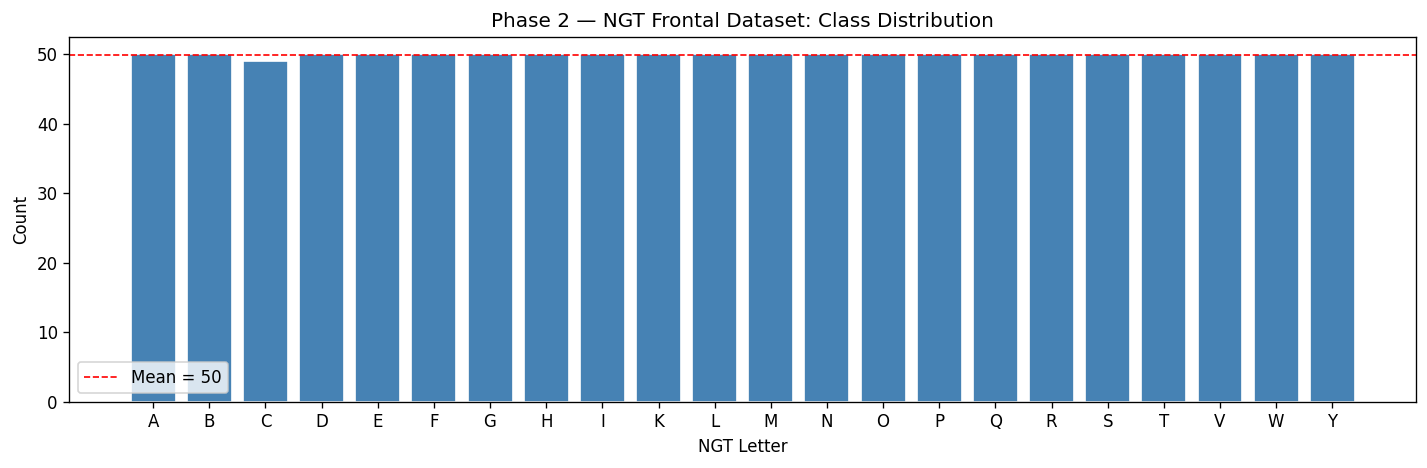

In [8]:
full_dataset = datasets.ImageFolder(str(DATA_DIR))
class_names = full_dataset.classes
targets = np.array(full_dataset.targets)

counts = Counter(targets)
labels = [class_names[i] for i in sorted(counts.keys())]
values = [counts[i] for i in sorted(counts.keys())]

print(f"Total images : {len(full_dataset)}")
print(f"Classes      : {NUM_CLASSES}")
print(f"Min per class: {min(values)}  |  Max: {max(values)}  |  Mean: {np.mean(values):.1f}")

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, values, color="steelblue", edgecolor="white")
ax.axhline(np.mean(values), color="red", ls="--", lw=1, label=f"Mean = {np.mean(values):.0f}")
ax.set_xlabel("NGT Letter"); ax.set_ylabel("Count")
ax.set_title("Phase 2 — NGT Frontal Dataset: Class Distribution")
ax.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "ngt_class_distribution.png"); plt.show()


### 2.3. Sample images per class

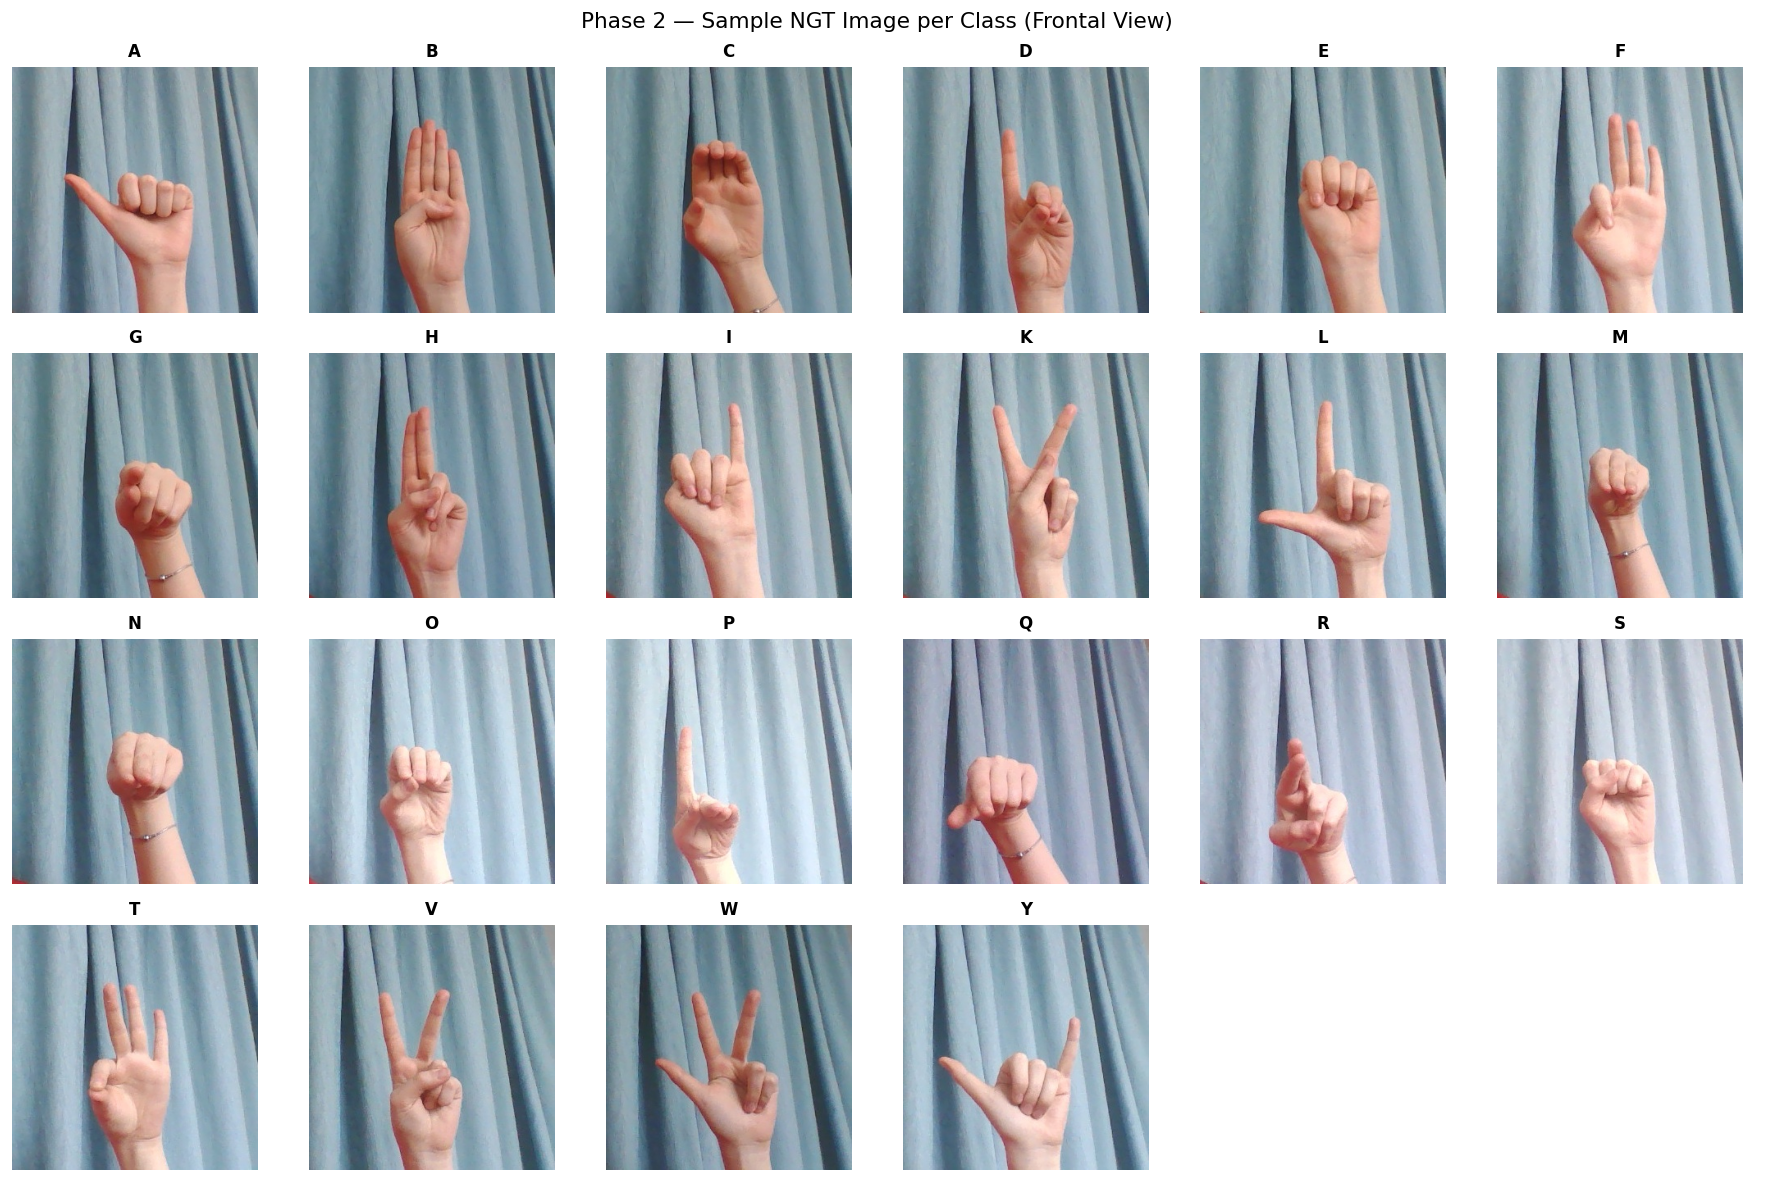

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
axes_flat = axes.flatten()

for i, cls_name in enumerate(class_names):
    cls_dir = DATA_DIR / cls_name
    imgs = sorted(cls_dir.glob("*.jpg")) + sorted(cls_dir.glob("*.png")) + sorted(cls_dir.glob("*.jpeg"))
    if imgs:
        img = Image.open(imgs[0]).convert("RGB")
        axes_flat[i].imshow(img)
        axes_flat[i].set_title(cls_name, fontsize=10, fontweight="bold")
    axes_flat[i].axis("off")

# Hide unused slots
for j in range(len(class_names), len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Phase 2 — Sample NGT Image per Class (Frontal View)", fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_sample_grid.png"); plt.show()

### 2.4. Image properties check

In [10]:
widths, heights, channels = [], [], []
corrupt_count = 0

for path, _ in full_dataset.samples:
    try:
        img = Image.open(path).convert("RGB")
        w, h = img.size
        widths.append(w); heights.append(h); channels.append(3)
    except Exception as e:
        corrupt_count += 1
        print(f"  ⚠ Corrupt: {path} — {e}")

print(f"\nImage property summary:")
print(f"  Resolutions : {min(widths)}×{min(heights)} to {max(widths)}×{max(heights)}")
print(f"  Unique sizes: {len(set(zip(widths, heights)))}")
print(f"  Corrupt     : {corrupt_count}")
if len(set(zip(widths, heights))) > 1:
    print("  → Mixed resolutions detected — transforms will resize to 224×224")


Image property summary:
  Resolutions : 300×300 to 300×300
  Unique sizes: 1
  Corrupt     : 0


### 2.5. Stratified train/val split with balance verification


Split: 879 train / 220 val  (ratio 0.2)


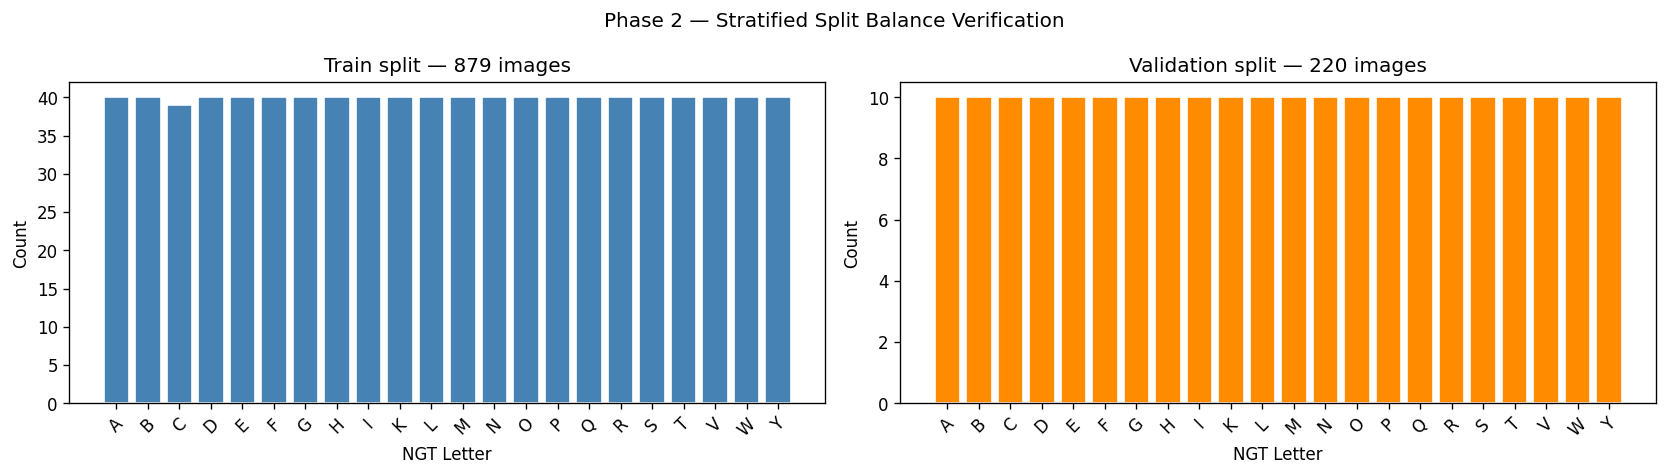

In [11]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

print(f"\nSplit: {len(train_idx)} train / {len(val_idx)} val  (ratio {VAL_SPLIT})")

# Verify class balance in both splits
train_counts = Counter(targets[train_idx])
val_counts = Counter(targets[val_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cnts, title in zip(axes, [train_counts, val_counts], ["Train", "Validation"]):
    vals = [cnts[i] for i in range(NUM_CLASSES)]
    ax.bar(class_names, vals, color="steelblue" if title == "Train" else "darkorange", edgecolor="white")
    ax.set_title(f"{title} split — {sum(vals)} images")
    ax.set_xlabel("NGT Letter"); ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Phase 2 — Stratified Split Balance Verification", fontsize=12)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_split_balance.png"); plt.show()

## 3. Data Pipelines

In [12]:
# Augmentation strategy for NGT fine-tuning:
# - ✅ Brightness/contrast shifts (±20%) — simulates lighting variation
# - ✅ Minor zoom/crop (RandomResizedCrop) — simulates hand position variation
# - ✅ Gaussian blur — simulates slight camera defocus
# - ✅ Color jitter — robustness to skin tone / background variation
# - ❌ NO rotation — rotation is the experimental variable (Phase 3)
# - ✅ Horizontal flip — simulates left-hand signing (data collected with right hand only)

In [13]:
# ImageNet normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # minor zoom
    transforms.RandomHorizontalFlip(p=0.5),                     # simulate left-hand signing
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [14]:
# Build datasets with appropriate transforms
train_dataset_full = datasets.ImageFolder(str(DATA_DIR), transform=train_transform)
val_dataset_full   = datasets.ImageFolder(str(DATA_DIR), transform=val_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset   = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train batches: 55  |  Val batches: 14


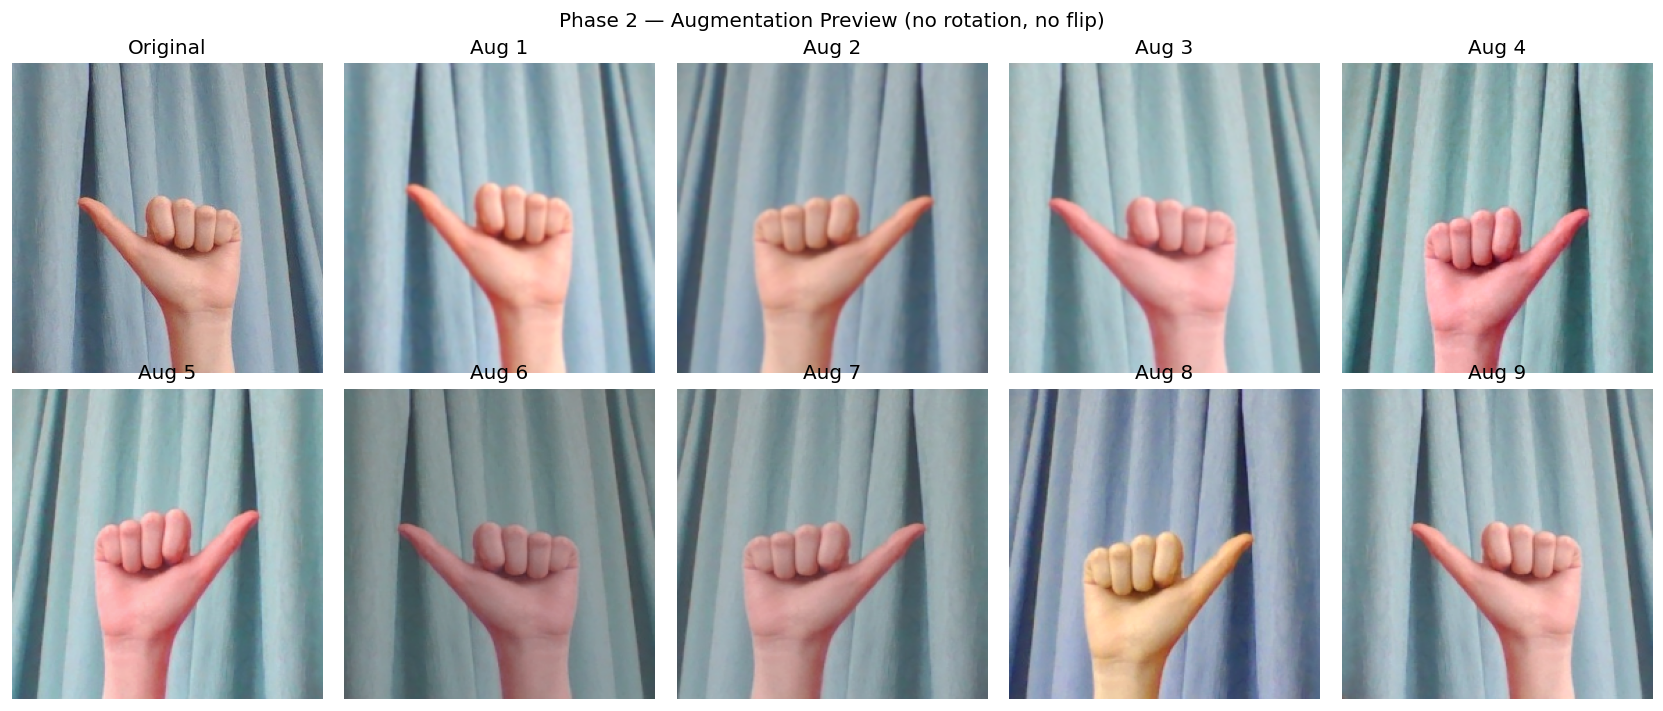

In [15]:
# visualize a batch of augmented training images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_img_path = full_dataset.samples[0][0]
orig_img = Image.open(sample_img_path).convert("RGB")
axes[0][0].imshow(orig_img); axes[0][0].set_title("Original"); axes[0][0].axis("off")

inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)
for i in range(1, 10):
    aug = train_transform(orig_img)
    aug_vis = inv_norm(aug).clamp(0, 1).permute(1, 2, 0).numpy()
    r, c = divmod(i, 5)
    axes[r][c].imshow(aug_vis); axes[r][c].set_title(f"Aug {i}"); axes[r][c].axis("off")

plt.suptitle("Phase 2 — Augmentation Preview (no rotation, no flip)", fontsize=12)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_augmentation_preview.png"); plt.show()

## 4. Model - Transfer learning from ASL base

In [ ]:
# Load EfficientNet-B0 weights from Phase 1 (ASL-trained):
# Replace the classifier head: 26 ASL classes → 22 NGT classes
# Freeze early feature extraction layers (blocks 0–5)
# Fine-tune only the last 2 blocks (6–7) + classifier head

In [ ]:
def build_model_from_asl(asl_ckpt_path, num_asl_classes=26, num_ngt_classes=22):
    """Load ASL-trained EfficientNet-B0 and adapt for NGT."""

    # Recreate the Phase 1 architecture
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_asl_classes)
    )

    # Load Phase 1 weights
    # Phase 1 checkpoint is a dict with keys: model_state, epoch, val_acc, class_names
    checkpoint = torch.load(asl_ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    print(f"✓ Loaded ASL checkpoint: {asl_ckpt_path.name}")
    print(f"  Trained for {checkpoint.get('epoch', '?')} epochs  |  Val acc: {checkpoint.get('val_acc', '?')}")
    print(f"  ASL classes: {checkpoint.get('class_names', '?')}")
    print(f"  Original head: {in_features} → {num_asl_classes} (ASL)")

    # Replace classifier head for NGT
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),  # slightly higher dropout — small dataset
        nn.Linear(in_features, num_ngt_classes)
    )
    print(f"  New head     : {in_features} → {num_ngt_classes} (NGT)")

    #  Freeze early layers, fine-tune last 2 feature blocks + head
    # EfficientNet-B0 features = [0]=stem, [1]..[7]=MBConv blocks, [8]=final conv+BN
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 2 MBConv blocks (features[6] and features[7])
    for block_idx in [6, 7]:
        for param in model.features[block_idx].parameters():
            param.requires_grad = True

    # Unfreeze the final conv + BN layer (features[8])
    for param in model.features[8].parameters():
        param.requires_grad = True

    # Unfreeze classifier head (always)
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Report trainable vs frozen
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"\n  Total params    : {total:,}")
    print(f"  Trainable       : {trainable:,} ({100*trainable/total:.1f}%)")
    print(f"  Frozen          : {frozen:,} ({100*frozen/total:.1f}%)")

    return model.to(device)

model = build_model_from_asl(ASL_CKPT, num_asl_classes=29, num_ngt_classes=NUM_CLASSES)

✓ Loaded ASL checkpoint: best_asl_model.pth
  Trained for 1 epochs  |  Val acc: 0.9989080459770115
  ASL classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
  Original head: 1280 → 29 (ASL)
  New head     : 1280 → 22 (NGT)

  Total params    : 4,035,730
  Trainable       : 3,183,922 (78.9%)
  Frozen          : 851,808 (21.1%)


## 5. Training

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Training loop
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    #Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validate
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    # Logging
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_DIR / "best_ngt_model.pth")
        status = f"  ✓ Saved best model (val_acc={val_acc:.4f})"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{status}")

    if patience_counter >= PATIENCE:
        print(f"  Early stopping at epoch {epoch}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
if best_val_acc >= TARGET_ACC:
    print(f"  ✓ Target accuracy ({TARGET_ACC:.0%}) ACHIEVED")
else:
    print(f"  ⚠ Below target ({TARGET_ACC:.0%}) — consider unfreezing more layers or adding augmentation")

# Save training history
with open(RESULTS_DIR / "ngt_training_history.json", "w") as f:
    json.dump(history, f, indent=2)


Epoch 01/30 | Train Loss: 2.3653  Acc: 0.7008 | Val Loss: 1.4232  Acc: 0.9591 | LR: 0.000100  ✓ Saved best model (val_acc=0.9591)
Epoch 02/30 | Train Loss: 1.2893  Acc: 0.9044 | Val Loss: 0.4747  Acc: 1.0000 | LR: 0.000100  ✓ Saved best model (val_acc=1.0000)
Epoch 03/30 | Train Loss: 0.5825  Acc: 0.9716 | Val Loss: 0.1676  Acc: 1.0000 | LR: 0.000099
Epoch 04/30 | Train Loss: 0.3029  Acc: 0.9886 | Val Loss: 0.0706  Acc: 1.0000 | LR: 0.000098
Epoch 05/30 | Train Loss: 0.1704  Acc: 0.9909 | Val Loss: 0.0360  Acc: 1.0000 | LR: 0.000096
Epoch 06/30 | Train Loss: 0.1153  Acc: 0.9966 | Val Loss: 0.0216  Acc: 1.0000 | LR: 0.000093
Epoch 07/30 | Train Loss: 0.0979  Acc: 0.9943 | Val Loss: 0.0137  Acc: 1.0000 | LR: 0.000091
Epoch 08/30 | Train Loss: 0.0760  Acc: 0.9898 | Val Loss: 0.0098  Acc: 1.0000 | LR: 0.000087
Epoch 09/30 | Train Loss: 0.0709  Acc: 0.9909 | Val Loss: 0.0064  Acc: 1.0000 | LR: 0.000084
  Early stopping at epoch 9

Best validation accuracy: 1.0000
  ✓ Target accuracy (85%) A

## 6. Evaluation

### 6.1. Training curves

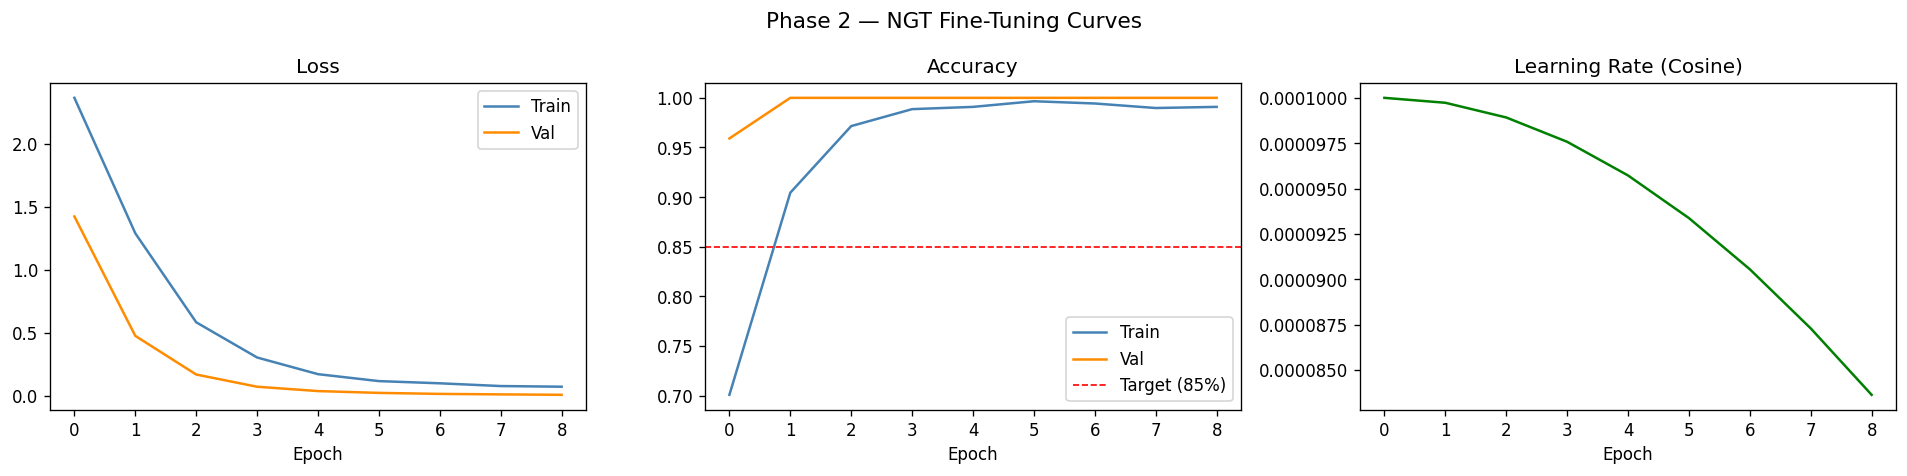

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(history["train_loss"], label="Train", color="steelblue")
axes[0].plot(history["val_loss"], label="Val", color="darkorange")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

# Accuracy curves
axes[1].plot(history["train_acc"], label="Train", color="steelblue")
axes[1].plot(history["val_acc"], label="Val", color="darkorange")
axes[1].axhline(TARGET_ACC, color="red", ls="--", lw=1, label=f"Target ({TARGET_ACC:.0%})")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

# Learning rate
axes[2].plot(history["lr"], color="green")
axes[2].set_title("Learning Rate (Cosine)"); axes[2].set_xlabel("Epoch")

plt.suptitle("Phase 2 — NGT Fine-Tuning Curves", fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_training_curves.png"); plt.show()


### 6.2. Best model & full evaluation

In [26]:
model.load_state_dict(torch.load(CKPT_DIR / "best_ngt_model.pth", map_location=device, weights_only=True))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [27]:
# classification report
print("=" * 60)
print("Phase 2 — NGT Classification Report")
print("=" * 60)
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# Save report
with open(RESULTS_DIR / "ngt_classification_report.txt", "w") as f:
    f.write(report)

# Summary metrics
val_accuracy  = (all_preds == all_labels).mean()
val_f1_macro  = f1_score(all_labels, all_preds, average="macro")
val_f1_weight = f1_score(all_labels, all_preds, average="weighted")
val_precision = precision_score(all_labels, all_preds, average="macro")
val_recall    = recall_score(all_labels, all_preds, average="macro")

print(f"\nOverall Accuracy  : {val_accuracy:.4f}")
print(f"Macro F1          : {val_f1_macro:.4f}")
print(f"Weighted F1       : {val_f1_weight:.4f}")
print(f"Macro Precision   : {val_precision:.4f}")
print(f"Macro Recall      : {val_recall:.4f}")

Phase 2 — NGT Classification Report
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        10
           B     1.0000    1.0000    1.0000        10
           C     1.0000    1.0000    1.0000        10
           D     1.0000    1.0000    1.0000        10
           E     1.0000    1.0000    1.0000        10
           F     1.0000    1.0000    1.0000        10
           G     1.0000    1.0000    1.0000        10
           H     1.0000    1.0000    1.0000        10
           I     1.0000    1.0000    1.0000        10
           K     1.0000    1.0000    1.0000        10
           L     1.0000    1.0000    1.0000        10
           M     1.0000    1.0000    1.0000        10
           N     1.0000    1.0000    1.0000        10
           O     1.0000    1.0000    1.0000        10
           P     1.0000    1.0000    1.0000        10
           Q     1.0000    1.0000    1.0000        10
           R     1.0000    1.0000    1.0000  

### 6.3. Confusion matrices

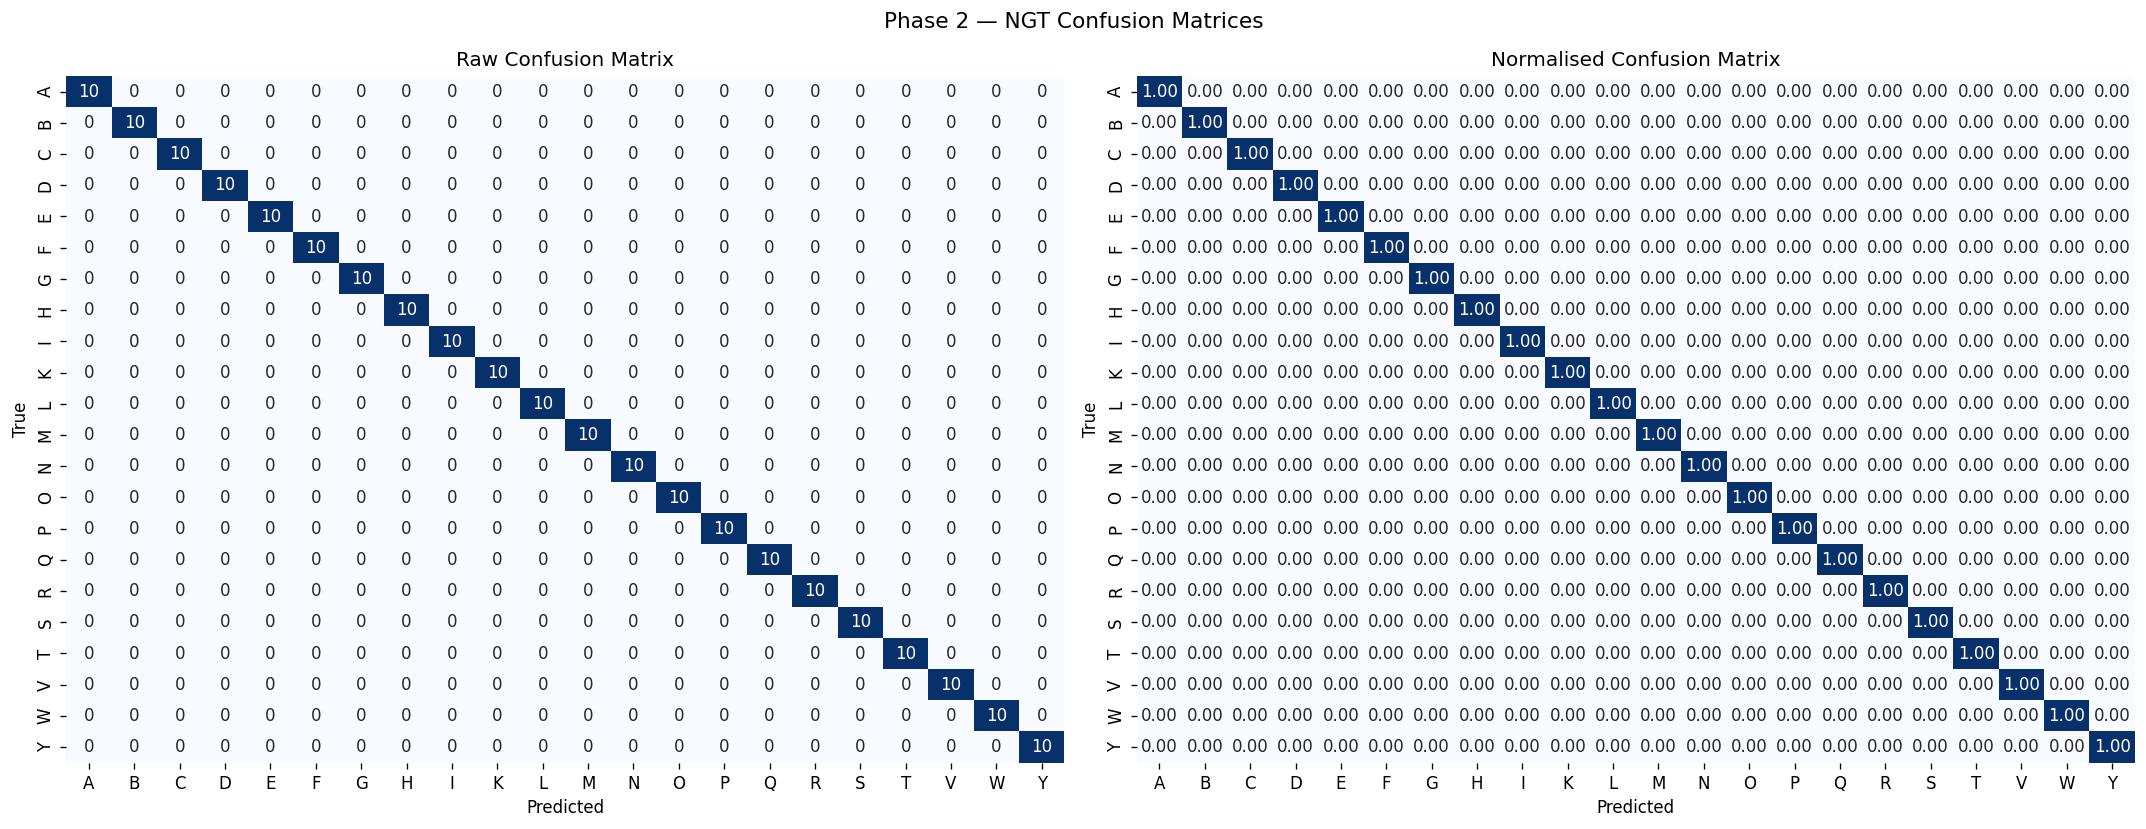

In [28]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[0], cbar=False)
axes[0].set_title("Raw Confusion Matrix"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[1], cbar=False)
axes[1].set_title("Normalised Confusion Matrix"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

plt.suptitle("Phase 2 — NGT Confusion Matrices", fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_confusion_matrices.png"); plt.show()

### 6.4. Per class accuracy bar chart

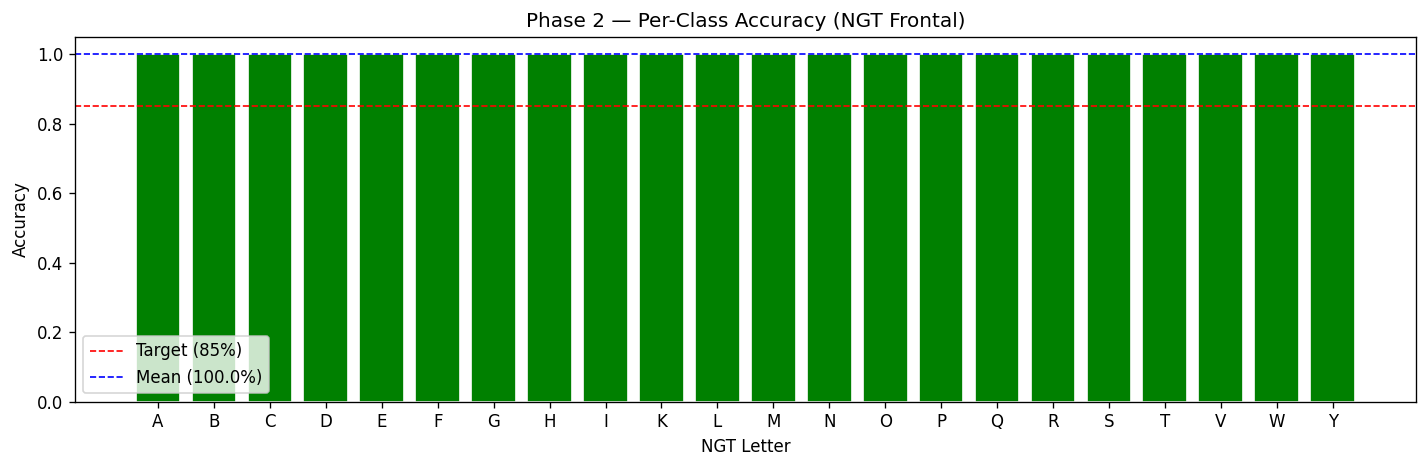


Bottom 5 classes:
   A: 100.00%
   B: 100.00%
   C: 100.00%
   D: 100.00%
   E: 100.00%


In [29]:
per_class_acc = cm_norm.diagonal()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["green" if a >= TARGET_ACC else "orange" if a >= 0.7 else "red" for a in per_class_acc]
ax.bar(class_names, per_class_acc, color=colors, edgecolor="white")
ax.axhline(TARGET_ACC, color="red", ls="--", lw=1, label=f"Target ({TARGET_ACC:.0%})")
ax.axhline(per_class_acc.mean(), color="blue", ls="--", lw=1, label=f"Mean ({per_class_acc.mean():.1%})")
ax.set_xlabel("NGT Letter"); ax.set_ylabel("Accuracy")
ax.set_title("Phase 2 — Per-Class Accuracy (NGT Frontal)")
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_per_class_accuracy.png"); plt.show()

# Print lowest-performing classes
sorted_idx = np.argsort(per_class_acc)
print("\nBottom 5 classes:")
for i in sorted_idx[:5]:
    print(f"  {class_names[i]:>2}: {per_class_acc[i]:.2%}")

### 6.5. Intelligent validation inspector

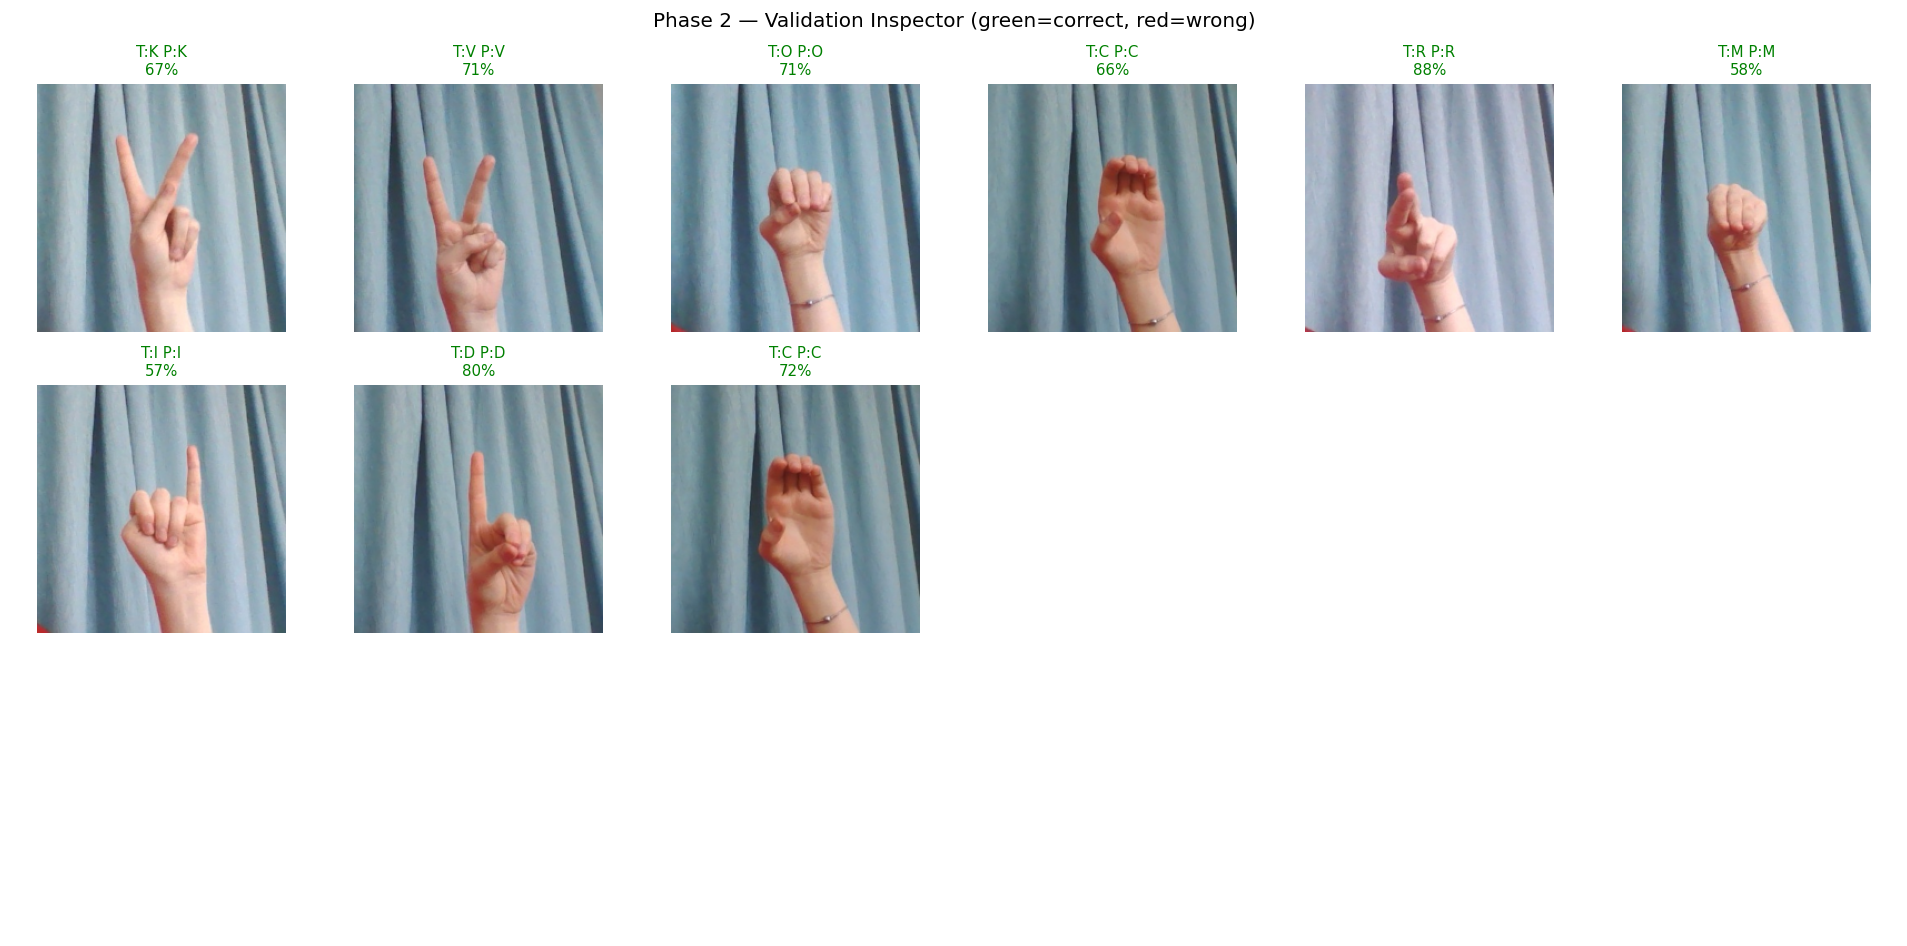

In [31]:
# Shows correct and incorrect predictions with confidence scores
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes_flat = axes.flatten()

inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

# Find misclassifications
wrong_mask = all_preds != all_labels
wrong_indices = np.where(wrong_mask)[0]
correct_indices = np.where(~wrong_mask)[0]

# Show 9 correct + 9 incorrect (or as many wrong as available)
n_wrong = min(9, len(wrong_indices))
n_correct = min(9, 18 - n_wrong)

show_indices = list(np.random.choice(correct_indices, n_correct, replace=False))
if n_wrong > 0:
    show_indices += list(np.random.choice(wrong_indices, n_wrong, replace=False))

for ax_idx, val_idx_pos in enumerate(show_indices[:18]):
    img_tensor = val_dataset[val_idx_pos][0]
    img_vis = inv_norm(img_tensor).clamp(0, 1).permute(1, 2, 0).numpy()

    true_label = class_names[all_labels[val_idx_pos]]
    pred_label = class_names[all_preds[val_idx_pos]]
    conf = all_probs[val_idx_pos].max()

    is_correct = true_label == pred_label
    color = "green" if is_correct else "red"

    axes_flat[ax_idx].imshow(img_vis)
    axes_flat[ax_idx].set_title(f"T:{true_label} P:{pred_label}\n{conf:.0%}", color=color, fontsize=9)
    axes_flat[ax_idx].axis("off")

for j in range(len(show_indices), 18):
    axes_flat[j].axis("off")

plt.suptitle("Phase 2 — Validation Inspector (green=correct, red=wrong)", fontsize=12)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_validation_inspector.png"); plt.show()

## 7. XAI - Grad-CAM & Grad-CAM++

In [32]:
# implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(module, input, output):
            self.activations = output.detach()
        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(fwd_hook)
        self.target_layer.register_full_backward_hook(bwd_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, output.softmax(1)[0, class_idx].item()


class GradCAMPP(GradCAM):
    """Grad-CAM++ — improved weighting using second and third derivatives."""
    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        score = output[0, class_idx]
        score.backward()

        grads = self.gradients
        acts = self.activations

        grads_2 = grads ** 2
        grads_3 = grads ** 3
        denom = 2.0 * grads_2 + (grads_3 * acts).sum(dim=(2, 3), keepdim=True) + 1e-8
        alpha = grads_2 / denom
        weights = (alpha * torch.relu(grads)).sum(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, output.softmax(1)[0, class_idx].item()


In [34]:
# target layer
target_layer = model.features[8]  # final conv + BN
grad_cam = GradCAM(model, target_layer)
grad_cam_pp = GradCAMPP(model, target_layer)

### 7.1. Side-by-side comparison for correct predictions

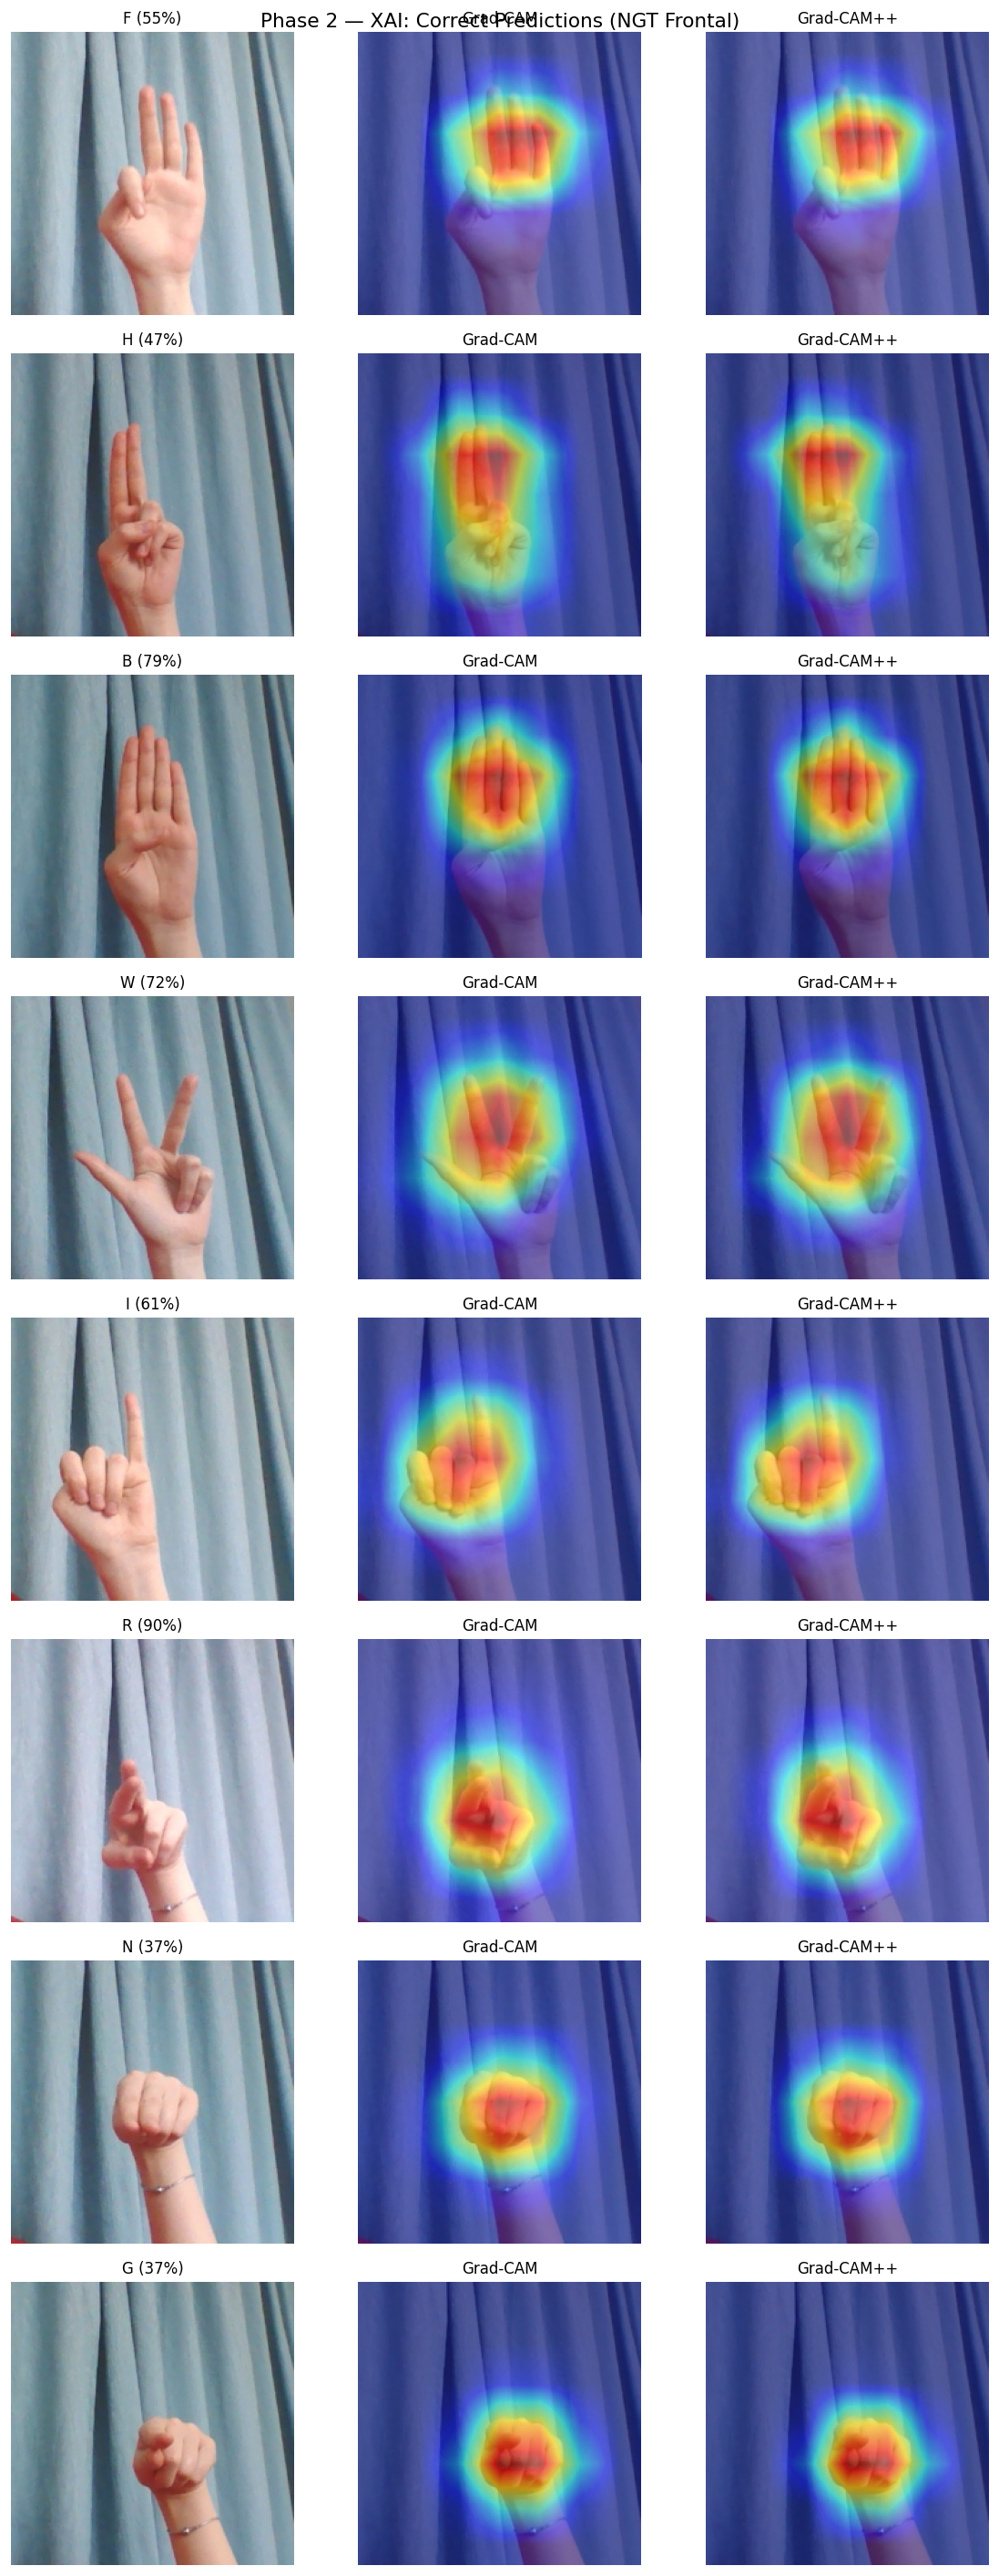

In [ ]:
model.eval()

# Select one correct prediction per class (up to 8 classes for readability)
sample_classes = np.random.choice(NUM_CLASSES, min(8, NUM_CLASSES), replace=False)
fig, axes = plt.subplots(len(sample_classes), 3, figsize=(10, 3 * len(sample_classes)))

for row, cls_idx in enumerate(sample_classes):
    mask = (all_labels == cls_idx) & (all_preds == cls_idx)
    if not mask.any():
        mask = all_labels == cls_idx  # fallback: any image of this class

    sample_pos = np.where(mask)[0][0]
    img_tensor = val_dataset[sample_pos][0].unsqueeze(0).to(device)
    img_vis = inv_norm(img_tensor.squeeze().cpu()).clamp(0, 1).permute(1, 2, 0).numpy()

    cam_gc, pred_idx, conf = grad_cam.generate(img_tensor)
    cam_pp, _, _ = grad_cam_pp.generate(img_tensor)

    axes[row][0].imshow(img_vis)
    axes[row][0].set_title(f"{class_names[cls_idx]} ({conf:.0%})", fontsize=10)
    axes[row][0].axis("off")

    axes[row][1].imshow(img_vis)
    axes[row][1].imshow(cam_gc, cmap="jet", alpha=0.5)
    axes[row][1].set_title("Grad-CAM", fontsize=10)
    axes[row][1].axis("off")

    axes[row][2].imshow(img_vis)
    axes[row][2].imshow(cam_pp, cmap="jet", alpha=0.5)
    axes[row][2].set_title("Grad-CAM++", fontsize=10)
    axes[row][2].axis("off")

plt.suptitle("Phase 2 — XAI: Correct Predictions (NGT Frontal)", fontsize=13)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_gradcam_correct.png"); plt.show()


### 7.2. Error analysis - missclassifications focus

In [ ]:
if len(wrong_indices) > 0:
    n_show = min(6, len(wrong_indices))
    sample_wrong = np.random.choice(wrong_indices, n_show, replace=False)

    fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for row, val_pos in enumerate(sample_wrong):
        img_tensor = val_dataset[val_pos][0].unsqueeze(0).to(device)
        img_vis = inv_norm(img_tensor.squeeze().cpu()).clamp(0, 1).permute(1, 2, 0).numpy()

        true_cls = class_names[all_labels[val_pos]]
        pred_cls = class_names[all_preds[val_pos]]

        cam_gc, _, conf = grad_cam.generate(img_tensor)
        cam_pp, _, _ = grad_cam_pp.generate(img_tensor)

        axes[row][0].imshow(img_vis)
        axes[row][0].set_title(f"True: {true_cls} → Pred: {pred_cls} ({conf:.0%})", fontsize=9, color="red")
        axes[row][0].axis("off")

        axes[row][1].imshow(img_vis); axes[row][1].imshow(cam_gc, cmap="jet", alpha=0.5)
        axes[row][1].set_title("Grad-CAM", fontsize=10); axes[row][1].axis("off")

        axes[row][2].imshow(img_vis); axes[row][2].imshow(cam_pp, cmap="jet", alpha=0.5)
        axes[row][2].set_title("Grad-CAM++", fontsize=10); axes[row][2].axis("off")

    plt.suptitle("Phase 2 — XAI: Misclassification Analysis", fontsize=13)
    plt.tight_layout(); plt.savefig(RESULTS_DIR / "ngt_gradcam_errors.png"); plt.show()
else:
    print("No misclassifications to analyse — model achieved 100% on validation set.")

No misclassifications to analyse — model achieved 100% on validation set.


## 8. Summary

In [37]:
print("=" * 60)
print("  PHASE 2 — NGT FINE-TUNING SUMMARY")
print("=" * 60)
print(f"  Model           : EfficientNet-B0 (ImageNet → ASL → NGT fine-tune)")
print(f"  ASL checkpoint  : {ASL_CKPT.name}")
print(f"  Dataset         : NGT Frontal ({len(full_dataset):,} images, {NUM_CLASSES} classes)")
print(f"  Val split       : {VAL_SPLIT:.0%} stratified (seed={SEED})")
print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} / {sum(p.numel() for p in model.parameters()):,}")
print(f"  Epochs trained  : {len(history['train_loss'])}")
print(f"  Best val acc    : {best_val_acc:.4f}  {'✓ TARGET MET' if best_val_acc >= TARGET_ACC else '⚠ BELOW TARGET'}")
print(f"  Accuracy        : {val_accuracy:.4f}")
print(f"  F1 (macro)      : {val_f1_macro:.4f}")
print(f"  F1 (weighted)   : {val_f1_weight:.4f}")
print(f"  Macro Precision : {val_precision:.4f}")
print(f"  Macro Recall    : {val_recall:.4f}")
print(f"  Best checkpoint : checkpoints/best_ngt_model.pth")
print("=" * 60)
print(f"\n  → This model is now ready for Phase 3 angle testing.")
print(f"  → Lowest-performing classes to watch:")
for i in sorted_idx[:3]:
    print(f"     {class_names[i]:>2}: {per_class_acc[i]:.2%}")
print("=" * 60)

  PHASE 2 — NGT FINE-TUNING SUMMARY
  Model           : EfficientNet-B0 (ImageNet → ASL → NGT fine-tune)
  ASL checkpoint  : best_asl_model.pth
  Dataset         : NGT Frontal (1,099 images, 22 classes)
  Val split       : 20% stratified (seed=42)
  Trainable params: 3,183,922 / 4,035,730
  Epochs trained  : 9
  Best val acc    : 1.0000  ✓ TARGET MET
  Accuracy        : 1.0000
  F1 (macro)      : 1.0000
  F1 (weighted)   : 1.0000
  Macro Precision : 1.0000
  Macro Recall    : 1.0000
  Best checkpoint : checkpoints/best_ngt_model.pth

  → This model is now ready for Phase 3 angle testing.
  → Lowest-performing classes to watch:
      A: 100.00%
      B: 100.00%
      C: 100.00%
